In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set a simple visual style for plots.
sns.set_theme(style="whitegrid")

In [2]:
PROJECT_ROOT = Path("..")

DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"

print("Project root:", PROJECT_ROOT.resolve())
print("Processed data path:", DATA_PROCESSED.resolve())

Project root: /workspaces/potential-pathway-index
Processed data path: /workspaces/potential-pathway-index/data/processed


In [3]:
early_behavior_dataset_path = DATA_PROCESSED / "early_behavior_dataset.csv"

print("Required input file:")
print(early_behavior_dataset_path)

print("\nFile exists:")
print(early_behavior_dataset_path.exists())

Required input file:
../data/processed/early_behavior_dataset.csv

File exists:
True


In [4]:
early_behavior_dataset = pd.read_csv(early_behavior_dataset_path)

print("early_behavior_dataset loaded successfully.")
print("Shape:", early_behavior_dataset.shape)

early_behavior_dataset.head()

early_behavior_dataset loaded successfully.
Shape: (32593, 39)


,id_student,code_module,code_presentation,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,...,max_score_30d,total_assessment_weight_30d,late_submission_count_30d,avg_days_late_30d,max_days_late_30d,first_submission_day_30d,last_submission_day_30d,banked_submissions_30d,has_assessment_submission_30d,has_assessment_score_30d
0,11391,AAA,2013J,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,...,78.0,10.0,0.0,0.0,0.0,18.0,18.0,0.0,1,1
1,28400,AAA,2013J,F,Scotland,HE Qualification,20-30%,35-55,0,60,...,70.0,10.0,1.0,3.0,3.0,22.0,22.0,0.0,1,1
2,30268,AAA,2013J,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,...,-1.0,0.0,0.0,0.0,0.0,-1.0,-1.0,0.0,0,0
3,31604,AAA,2013J,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,...,72.0,10.0,0.0,0.0,0.0,17.0,17.0,0.0,1,1
4,32885,AAA,2013J,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,...,69.0,10.0,1.0,7.0,7.0,26.0,26.0,0.0,1,1


In [5]:
main_keys = ["id_student", "code_module", "code_presentation"]

total_rows = early_behavior_dataset.shape[0]
unique_keys = early_behavior_dataset[main_keys].drop_duplicates().shape[0]

print("Total rows:", total_rows)
print("Unique student-module-presentation keys:", unique_keys)
print("Is the main key unique?", total_rows == unique_keys)

Total rows: 32593
Unique student-module-presentation keys: 32593
Is the main key unique? True


In [6]:
print("Number of columns:", early_behavior_dataset.shape[1])

early_behavior_dataset.columns.tolist()

Number of columns: 39


['id_student',
 'code_module',
 'code_presentation',
 'gender',
 'region',
 'highest_education',
 'imd_band',
 'age_band',
 'num_of_prev_attempts',
 'studied_credits',
 'disability',
 'date_registration',
 'final_result',
 'at_risk_misalignment',
 'total_clicks_30d',
 'active_days_30d',
 'avg_clicks_per_active_day_30d',
 'max_clicks_single_day_30d',
 'std_clicks_active_day_30d',
 'first_activity_day_30d',
 'last_activity_day_30d',
 'activity_span_30d',
 'days_since_last_activity_30d',
 'has_vle_activity_30d',
 'submitted_assessments_30d',
 'scored_assessments_30d',
 'missing_score_submissions_30d',
 'avg_score_30d',
 'min_score_30d',
 'max_score_30d',
 'total_assessment_weight_30d',
 'late_submission_count_30d',
 'avg_days_late_30d',
 'max_days_late_30d',
 'first_submission_day_30d',
 'last_submission_day_30d',
 'banked_submissions_30d',
 'has_assessment_submission_30d',
 'has_assessment_score_30d']

In [7]:
missing_values = early_behavior_dataset.isnull().sum().sort_values(ascending=False)

missing_values[missing_values > 0]

imd_band             1111
date_registration      45
dtype: int64

In [8]:
target_distribution = early_behavior_dataset["at_risk_misalignment"].value_counts().sort_index()
target_percentage = early_behavior_dataset["at_risk_misalignment"].value_counts(normalize=True).sort_index() * 100

target_summary = pd.DataFrame({
    "count": target_distribution,
    "percentage": target_percentage.round(2)
})

target_summary

,count,percentage
at_risk_misalignment,,
0,15385,47.2
1,17208,52.8


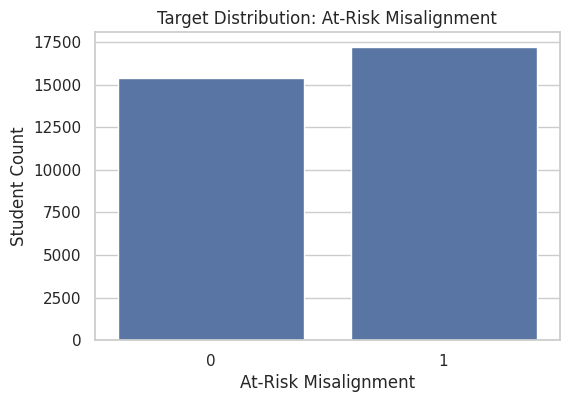

In [9]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=early_behavior_dataset,
    x="at_risk_misalignment"
)

plt.title("Target Distribution: At-Risk Misalignment")
plt.xlabel("At-Risk Misalignment")
plt.ylabel("Student Count")

plt.show()

In [10]:
behavior_flag_columns = [
    "has_vle_activity_30d",
    "has_assessment_submission_30d",
    "has_assessment_score_30d"
]

print("Behavior availability columns:")
print(behavior_flag_columns)

Behavior availability columns:
['has_vle_activity_30d', 'has_assessment_submission_30d', 'has_assessment_score_30d']


In [11]:
behavior_availability_by_target = (
    early_behavior_dataset
    .groupby("at_risk_misalignment")[behavior_flag_columns]
    .mean()
    .T
)

behavior_availability_by_target.columns = [
    "stable_0",
    "at_risk_1"
]

behavior_availability_by_target["difference_at_risk_minus_stable"] = (
    behavior_availability_by_target["at_risk_1"]
    - behavior_availability_by_target["stable_0"]
)

behavior_availability_by_target

,stable_0,at_risk_1,difference_at_risk_minus_stable
has_vle_activity_30d,0.986480,0.743491,-0.242989
has_assessment_submission_30d,0.802535,0.486576,-0.315959
has_assessment_score_30d,0.802535,0.485879,-0.316656


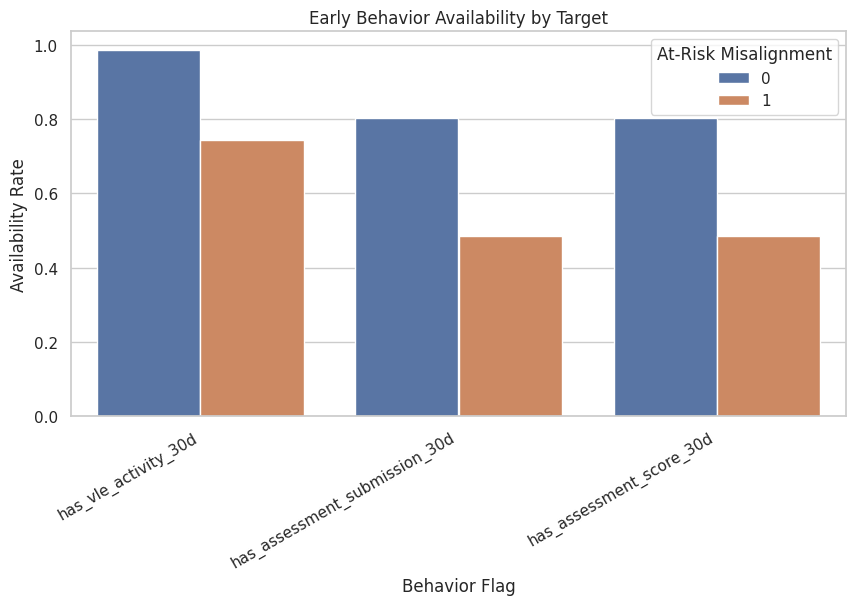

In [12]:
behavior_plot_data = (
    early_behavior_dataset
    .groupby("at_risk_misalignment")[behavior_flag_columns]
    .mean()
    .reset_index()
    .melt(
        id_vars="at_risk_misalignment",
        value_vars=behavior_flag_columns,
        var_name="behavior_flag",
        value_name="availability_rate"
    )
)

plt.figure(figsize=(10, 5))

sns.barplot(
    data=behavior_plot_data,
    x="behavior_flag",
    y="availability_rate",
    hue="at_risk_misalignment"
)

plt.title("Early Behavior Availability by Target")
plt.xlabel("Behavior Flag")
plt.ylabel("Availability Rate")
plt.xticks(rotation=30, ha="right")
plt.legend(title="At-Risk Misalignment")

plt.show()

In [13]:
vle_feature_columns = [
    "total_clicks_30d",
    "active_days_30d",
    "avg_clicks_per_active_day_30d",
    "max_clicks_single_day_30d",
    "std_clicks_active_day_30d",
    "activity_span_30d",
    "days_since_last_activity_30d"
]

assessment_feature_columns = [
    "submitted_assessments_30d",
    "scored_assessments_30d",
    "avg_score_30d",
    "min_score_30d",
    "max_score_30d",
    "total_assessment_weight_30d",
    "late_submission_count_30d",
    "avg_days_late_30d",
    "max_days_late_30d",
    "banked_submissions_30d"
]

behavior_feature_columns = vle_feature_columns + assessment_feature_columns

print("Number of behavior features:", len(behavior_feature_columns))
print(behavior_feature_columns)

Number of behavior features: 17
['total_clicks_30d', 'active_days_30d', 'avg_clicks_per_active_day_30d', 'max_clicks_single_day_30d', 'std_clicks_active_day_30d', 'activity_span_30d', 'days_since_last_activity_30d', 'submitted_assessments_30d', 'scored_assessments_30d', 'avg_score_30d', 'min_score_30d', 'max_score_30d', 'total_assessment_weight_30d', 'late_submission_count_30d', 'avg_days_late_30d', 'max_days_late_30d', 'banked_submissions_30d']


In [14]:
behavior_means_by_target = (
    early_behavior_dataset
    .groupby("at_risk_misalignment")[behavior_feature_columns]
    .mean()
    .T
)

behavior_means_by_target.columns = [
    "stable_0",
    "at_risk_1"
]

behavior_means_by_target["difference_at_risk_minus_stable"] = (
    behavior_means_by_target["at_risk_1"]
    - behavior_means_by_target["stable_0"]
)

behavior_means_by_target

,stable_0,at_risk_1,difference_at_risk_minus_stable
total_clicks_30d,368.644394,160.403359,-208.241035
active_days_30d,13.799610,6.937529,-6.862081
avg_clicks_per_active_day_30d,23.140284,15.048859,-8.091425
max_clicks_single_day_30d,79.281443,45.374245,-33.907198
std_clicks_active_day_30d,22.599668,14.258697,-8.340971
activity_span_30d,25.627559,15.673117,-9.954442
days_since_last_activity_30d,2.809945,12.425093,9.615148
submitted_assessments_30d,0.975431,0.549628,-0.425803
scored_assessments_30d,0.975431,0.548640,-0.426790
avg_score_30d,62.293912,31.580689,-30.713223


In [15]:
behavior_mean_differences = behavior_means_by_target.copy()

behavior_mean_differences["absolute_difference"] = (
    behavior_mean_differences["difference_at_risk_minus_stable"].abs()
)

behavior_mean_differences = behavior_mean_differences.sort_values(
    by="absolute_difference",
    ascending=False
)

behavior_mean_differences

,stable_0,at_risk_1,difference_at_risk_minus_stable,absolute_difference
total_clicks_30d,368.644394,160.403359,-208.241035,208.241035
max_clicks_single_day_30d,79.281443,45.374245,-33.907198,33.907198
max_score_30d,63.066103,31.974837,-31.091266,31.091266
avg_score_30d,62.293912,31.580689,-30.713223,30.713223
min_score_30d,61.478843,31.180846,-30.297997,30.297997
activity_span_30d,25.627559,15.673117,-9.954442,9.954442
days_since_last_activity_30d,2.809945,12.425093,9.615148,9.615148
std_clicks_active_day_30d,22.599668,14.258697,-8.340971,8.340971
avg_clicks_per_active_day_30d,23.140284,15.048859,-8.091425,8.091425
active_days_30d,13.799610,6.937529,-6.862081,6.862081
